In [1]:
!pip3 install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


## DBSCAN Algorithm Implementation

In [40]:
# Add Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os
import time
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score, calinski_harabasz_score, adjusted_mutual_info_score, mutual_info_score
from collections import deque
from scipy.sparse import issparse
import importlib
import common.functions
importlib.reload(common.functions)

from common.functions import compute_gower_distance, visualize_clusters, compute_gower_distance_matrix


### Load datasets

In [52]:
dataset_path = "./../datasets"

global_earthquake_data_path = dataset_path + "/earthquakes.csv"

In [ ]:
global_earthquake_data_df = pd.read_csv(global_earthquake_data_path)

earthquake_drop_cols = [
    'id', 'title', 'date', 'time', 'updated', 'url', 'detailUrl', 
    'ids', 'sources', 'types', 'place', 'placeOnly', 'location', 
    'what3words', 'locationDetails'
]
global_earthquake_data_df = global_earthquake_data_df.drop(columns=earthquake_drop_cols)

earthquake_categorical_cols = [
    'type', 'status', 'net', 'magType', 'geometryType',
    'continent', 'country', 'subnational', 'city', 'locality', 'postcode', 'timezone'
]
earthquake_numerical_cols = [
    "magnitude", "felt", "cdi", "mmi", "tsunami", "sig",
    "nst", "dmin", "rms", "gap", "depth", "latitude",
    "longitude", "distanceKM"
]

# global_earthquake_data_df = pd.get_dummies(global_earthquake_data_df, columns=earthquake_categorical_cols)

datasets = {
    "global_earthquake": global_earthquake_data_df
}

In [55]:
le = LabelEncoder()
global_earthquake_data_df['alert'] = le.fit_transform(global_earthquake_data_df['alert'])

# Separate features and target
X = global_earthquake_data_df.drop('alert', axis=1)  
y = global_earthquake_data_df['alert']

# Build a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), earthquake_categorical_cols),  
        ('num', 'passthrough', earthquake_numerical_cols) 
    ], 
    remainder='drop'
)

X_encoded = preprocessor.fit_transform(X)

# Get the feature names from the one-hot encoder transformer
onehot_columns = preprocessor.named_transformers_['cat'].get_feature_names_out(earthquake_categorical_cols)
all_columns = list(onehot_columns) + earthquake_numerical_cols

# Compute mutual information scores relative to 'alert'
mi_scores = mutual_info_classif(X_encoded, y)
mi_df = pd.DataFrame({'Feature': all_columns, 'MI Score': mi_scores})
mi_df.sort_values(by='MI Score', ascending=False, inplace=True)

# Extract the top 5 features based on mutual information
top_5_features = mi_df.head(5)
print("Top 5 features based on mutual information:")
print(top_5_features)

top_feature_names = top_5_features['Feature'].tolist()
top_feature_indices = [all_columns.index(feat) for feat in top_feature_names]

X_top5 = X_encoded[:, top_feature_indices]

Top 5 features based on mutual information:
       Feature  MI Score
657  longitude  0.829265
656   latitude  0.823230
650        sig  0.766033
652       dmin  0.715656
655      depth  0.631952


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: 

### DBSCAN Algorithm stated in report (see report/Part-I.pdf)

In [56]:
class CustomDBSCAN:
    def __init__(self, eps=0.5, min_pts=5, metric='euclidean'):
        self.eps = eps
        self.min_pts = min_pts
        self.metric = metric
        self.labels_ = None

    def _region_query(self, X, point_idx):
        if self.metric == 'precomputed':
            distances = X[point_idx, :]
        else:
            distances = np.linalg.norm(X - X[point_idx], axis=1)
        neighbors = np.where(distances <= self.eps)[0]
        return neighbors

    def _expand_cluster(self, X, point_idx, neighbors, cluster_id, labels):
        labels[point_idx] = cluster_id
        neighbors_queue = deque(neighbors)
        while neighbors_queue:
            neighbor_idx = neighbors_queue.popleft()
            if labels[neighbor_idx] == -2:  # unvisited
                labels[neighbor_idx] = -1   # mark as visited (temporarily noise)
                neighbor_neighbors = self._region_query(X, neighbor_idx)
                if len(neighbor_neighbors) >= self.min_pts:
                    neighbors_queue.extend(neighbor_neighbors)
            if labels[neighbor_idx] == -1:  # if it was noise, now assign it to the cluster
                labels[neighbor_idx] = cluster_id

    def fit(self, X):
        n = X.shape[0]
        # Initialize all points as unvisited (-2). -1 will denote noise.
        labels = np.full(n, -2, dtype=int)
        cluster_id = 0

        for i in range(n):
            if labels[i] != -2:  # already processed
                continue
            labels[i] = -1  # mark as noise initially
            neighbors = self._region_query(X, i)
            if len(neighbors) < self.min_pts:
                continue  # remains noise
            else:
                cluster_id += 1
                self._expand_cluster(X, i, neighbors, cluster_id, labels)
        self.labels_ = labels
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

In [63]:
# how many different alerts are there?
num_alerts = len(global_earthquake_data_df['alert'].unique())
print(f"Number of different alerts: {num_alerts}")

# percentages of each alert in the dataset, shown as `name of the alert`-`percentage`
alert_counts = global_earthquake_data_df['alert'].value_counts(normalize=True) * 100
alert_counts = alert_counts.round(2).astype(str) + '%'
print("Percentages of each alert in the dataset:")
for alert, percentage in alert_counts.items():
    print(f"{alert} - {percentage}")

Number of different alerts: 5
Percentages of each alert in the dataset:
0 - 62.53%
4 - 32.81%
3 - 3.34%
2 - 0.79%
1 - 0.53%


### Comparing our custom implementation with that of Sci-kit Learn's

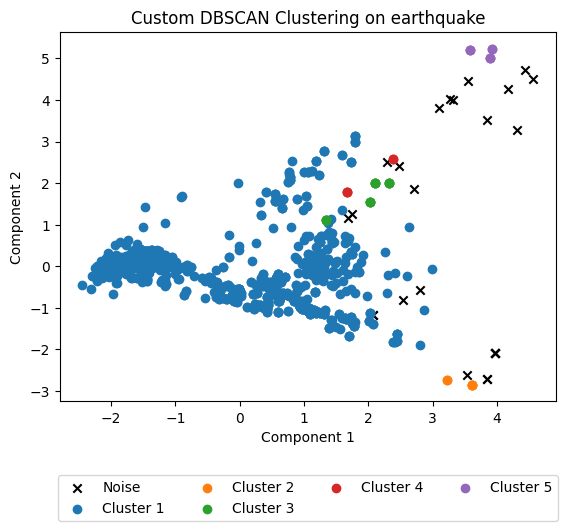

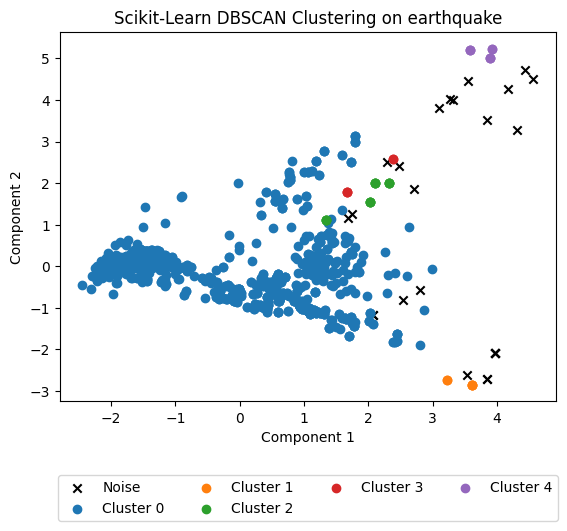

In [61]:
# earthquake_relevant_df = global_earthquake_data_df[top_feature_names]
# X = earthquake_relevant_df.values
X = global_earthquake_data_df[top_feature_names].values
X = StandardScaler().fit_transform(X)

# ---------------------------
# Run Custom DBSCAN
# ---------------------------
custom_dbscan = CustomDBSCAN(eps=1.5, min_pts=5)
start_time = time.time()
labels_custom = custom_dbscan.fit_predict(X)
custom_runtime = time.time() - start_time

custom_silhouette = silhouette_score(X, labels_custom) if len(set(labels_custom)) > 1 else None

results = []
results.append({
    "dataset": 'earthquake',
    "type": "custom",
    "metric": 'euclidean',
    "silhouette": custom_silhouette,
    "runtime": custom_runtime,
    "cluster_count": len(set(labels_custom)) - (1 if -1 in labels_custom else 0),
    "noise_count": list(labels_custom).count(-1),
})

# Visualize the clusters (assuming visualize_clusters is defined)
visualize_clusters(X, labels_custom, "Custom DBSCAN Clustering on earthquake", saveAs="top_5_custom_dbscan_earthquake.png")

# ---------------------------
# Scikit-Learn DBSCAN Implementation
# ---------------------------
start_time = time.time()
sklearn_dbscan = SklearnDBSCAN(eps=1.5, min_samples=5)
labels_sklearn = sklearn_dbscan.fit_predict(X)
sklearn_runtime = time.time() - start_time

sklearn_silhouette = silhouette_score(X, labels_sklearn) if len(set(labels_sklearn)) > 1 else None
results.append({
    "dataset": 'earthquake',
    "type": "sklearn",
    "metric": 'euclidean',
    "silhouette": sklearn_silhouette,
    "runtime": sklearn_runtime,
    "cluster_count": len(set(labels_sklearn)) - (1 if -1 in labels_sklearn else 0),
    "noise_count": list(labels_sklearn).count(-1),
})
visualize_clusters(X, labels_sklearn, "Scikit-Learn DBSCAN Clustering on earthquake", saveAs="top_5_scilearn_dbscan_earthquake.png")

results_df = pd.DataFrame(results)
results_df.to_csv("dbscan_05_results.csv", index=False)